# Air Quality Insights & Predictions
## Analysis - Which Areas Need Attention?
This notebook analyzes the air quality data to find patterns, identify worst and best performing states, and make predictions about future trends.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
data = pd.read_csv('../Data/processed/clean_data.csv')

print("Data loaded successfully!")
print(f"Total Records: {len(data):,}")
print(f"States: {data['state'].nunique()}")
print(f"Areas: {data['area'].nunique()}")
print(f"Date Range: {data['date'].min()} to {data['date'].max()}")


Data loaded successfully!
Total Records: 425,138
States: 32
Areas: 295
Date Range: 2015-05-15 to 2025-06-19


# Most Polluted States

Top 10 Most Polluted States:
1. delhi: 215.8
2. bihar: 165.9
3. himachal pradesh: 160.1
4. uttar pradesh: 159.6
5. haryana: 151.5
6. jharkhand: 147.4
7. rajasthan: 130.7
8. tripura: 126.6
9. odisha: 123.7
10. chandigarh: 122.8


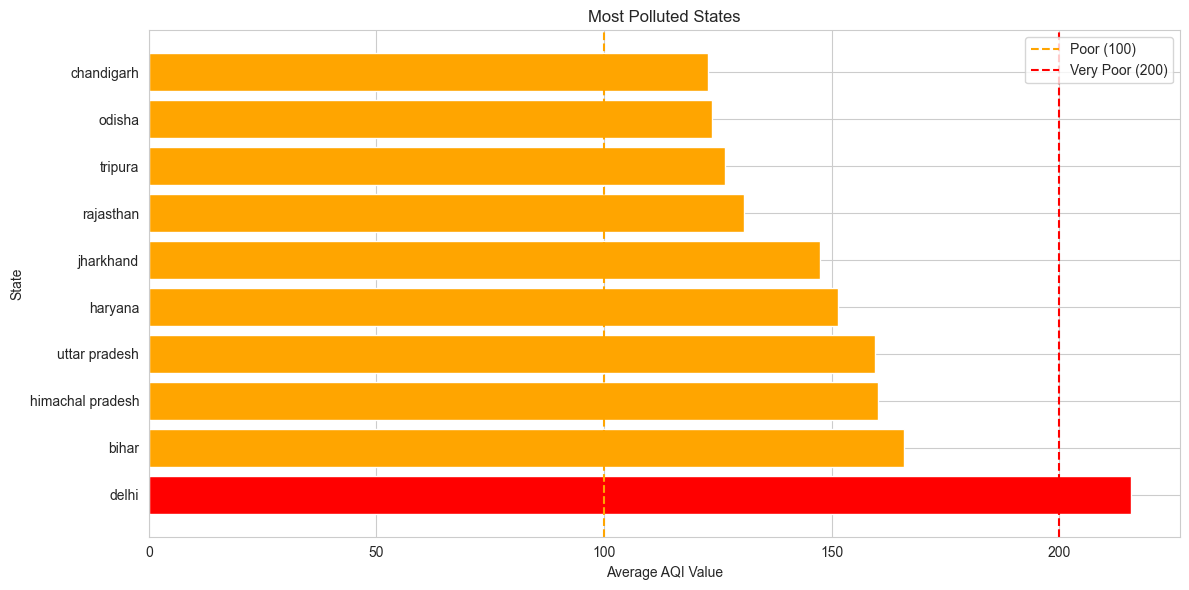

In [2]:
worst_states = data.groupby('state')['aqi_value'].mean().sort_values(ascending=False).head(10)

print("Top 10 Most Polluted States:")

for rank, (state, aqi) in enumerate(worst_states.items(), 1):
    print(f"{rank}. {state}: {aqi:.1f}")

plt.figure(figsize=(12, 6))

bar_colors = []
for aqi_value in worst_states.values:
    if aqi_value > 200:
        bar_colors.append('red')        
    elif aqi_value > 100:
        bar_colors.append('orange')     
    else:
        bar_colors.append('green')      


plt.barh(worst_states.index, worst_states.values, color=bar_colors)

plt.axvline(x=100, color='orange', linestyle='--', label='Poor (100)')
plt.axvline(x=200, color='red', linestyle='--', label='Very Poor (200)')

plt.xlabel('Average AQI Value')
plt.ylabel('State')
plt.title('Most Polluted States')
plt.legend()
plt.tight_layout()
plt.show()


## Cleanest States

Top 10 Cleanest States:
1. mizoram: 45.1 (GOOD)
2. meghalaya: 52.6 (SATISFACTORY)
3. sikkim: 53.5 (SATISFACTORY)
4. puducherry: 56.0 (SATISFACTORY)
5. arunachal pradesh: 59.9 (SATISFACTORY)
6. andaman and nicobar islands: 60.5 (SATISFACTORY)
7. karnataka: 64.3 (SATISFACTORY)
8. kerala: 67.5 (SATISFACTORY)
9. tamil nadu: 69.8 (SATISFACTORY)
10. chhattisgarh: 77.8 (SATISFACTORY)


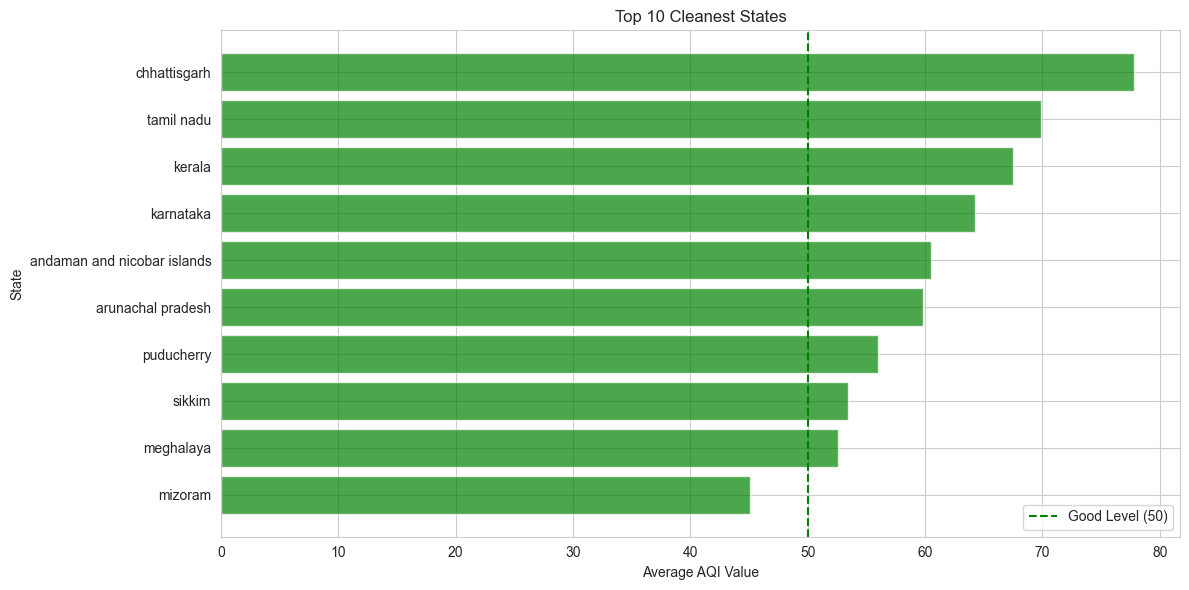

In [3]:
best_states = data.groupby('state')['aqi_value'].mean().sort_values(ascending=True).head(10)

print("Top 10 Cleanest States:")

for rank, (state, aqi) in enumerate(best_states.items(), 1):
    if aqi < 50:
        quality = "GOOD"
    else:
        quality = "SATISFACTORY"
    
    print(f"{rank}. {state}: {aqi:.1f} ({quality})")

plt.figure(figsize=(12, 6))

plt.barh(best_states.index, best_states.values, color='green', alpha=0.7)

plt.axvline(x=50, color='green', linestyle='--', label='Good Level (50)')

plt.xlabel('Average AQI Value')
plt.ylabel('State')
plt.title('Top 10 Cleanest States')
plt.legend()
plt.tight_layout()
plt.show()


## Seasonal Patterns

Monthly Air Quality Trends:
Jan: AQI = 163.0 
Feb: AQI = 137.8 
Mar: AQI = 121.2 
Apr: AQI = 117.2 
May: AQI = 107.2 
Jun: AQI = 94.2 
Jul: AQI = 67.4 
Aug: AQI = 66.2 (BEST)
Sep: AQI = 70.4 
Oct: AQI = 120.9 
Nov: AQI = 174.3 (WORST)
Dec: AQI = 168.2 


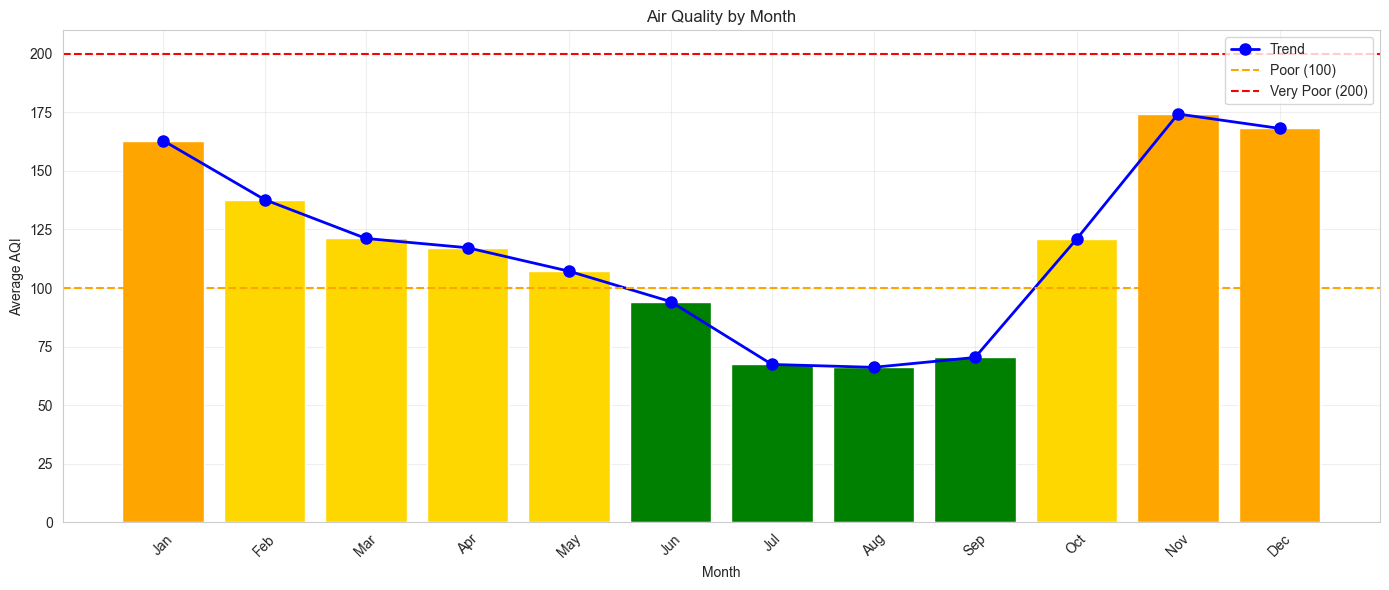


Worst Month: Nov (AQI: 174.3)
Best Month: Aug (AQI: 66.2)


In [4]:

monthly_avg = data.groupby('month')['aqi_value'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

worst_month = monthly_avg.idxmax()
best_month = monthly_avg.idxmin()

print("Monthly Air Quality Trends:")


for month in range(1, 13):
    aqi_value = monthly_avg[month]
    
    if month == worst_month:
        status = "(WORST)"
    elif month == best_month:
        status = "(BEST)"
    else:
        status = ""
    
    print(f"{month_names[month-1]}: AQI = {aqi_value:.1f} {status}")

plt.figure(figsize=(14, 6))

bar_colors = []
for aqi_value in monthly_avg.values:
    if aqi_value > 200:
        bar_colors.append('red')           
    elif aqi_value > 150:
        bar_colors.append('orange')        
    elif aqi_value > 100:
        bar_colors.append('gold')          
    else:
        bar_colors.append('green')        


plt.bar(range(1, 13), monthly_avg.values, color=bar_colors)

plt.plot(range(1, 13), monthly_avg.values, 'b-o', linewidth=2, markersize=8, label='Trend')

plt.axhline(y=100, color='orange', linestyle='--', label='Poor (100)')
plt.axhline(y=200, color='red', linestyle='--', label='Very Poor (200)')

plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.title('Air Quality by Month')
plt.xticks(range(1, 13), month_names, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nWorst Month: {month_names[worst_month-1]} (AQI: {monthly_avg[worst_month]:.1f})")
print(f"Best Month: {month_names[best_month-1]} (AQI: {monthly_avg[best_month]:.1f})")

## Critical State-Month Combinations
Which state-month pairs have the worst air quality?

In [6]:

state_month_avg = data.groupby(['state', 'month'])['aqi_value'].mean().sort_values(ascending=False).head(15)

print("<<<---  15 Most Dangerous State-Month Combinations -->>>")
for rank, ((state, month), aqi) in enumerate(state_month_avg.items(), 1):
    month_name = month_names[month-1]
    print(f"{rank:2d}. {state:20} in {month_name:4} → AQI: {aqi:6.1f}")

<<<---  15 Most Dangerous State-Month Combinations -->>>
 1. delhi                in Nov  → AQI:  351.2
 2. delhi                in Dec  → AQI:  330.8
 3. delhi                in Jan  → AQI:  318.9
 4. bihar                in Dec  → AQI:  267.8
 5. uttar pradesh        in Nov  → AQI:  263.0
 6. himachal pradesh     in Jan  → AQI:  262.8
 7. bihar                in Jan  → AQI:  259.2
 8. haryana              in Nov  → AQI:  252.6
 9. delhi                in Feb  → AQI:  246.9
10. delhi                in Oct  → AQI:  242.0
11. uttar pradesh        in Dec  → AQI:  242.0
12. bihar                in Nov  → AQI:  241.9
13. himachal pradesh     in Dec  → AQI:  223.8
14. uttar pradesh        in Jan  → AQI:  223.3
15. tripura              in Jan  → AQI:  222.3


## Trend Analysis
### Are the worst states getting better or worse over time?

In [9]:

print("Trend Analysis - Top 10 Worst States:")
print("(Comparing early period vs recent period)")
worst_10_states = worst_states.head(10).index.tolist()
trends = []

for state in worst_10_states:
    state_data = data[data['state'] == state].sort_values('date')
    
    mid_point = len(state_data) // 2
    early_aqi = state_data.iloc[:mid_point]['aqi_value'].mean()
    recent_aqi = state_data.iloc[mid_point:]['aqi_value'].mean()
    change = recent_aqi - early_aqi
    change_pct = (change / early_aqi) * 100
    
    trend = "WORSENING" if change > 0 else "IMPROVING"
    print(f"{state:20} → {trend:10} ({change:+.1f} AQI, {change_pct:+.1f}%)")
    trends.append((state, change))

print("\nPositive change = Worsening, Negative change = Improving")

Trend Analysis - Top 10 Worst States:
(Comparing early period vs recent period)
delhi                → IMPROVING  (-19.8 AQI, -8.8%)
bihar                → IMPROVING  (-57.1 AQI, -29.4%)
himachal pradesh     → WORSENING  (+16.0 AQI, +10.5%)
uttar pradesh        → IMPROVING  (-69.3 AQI, -35.7%)
haryana              → IMPROVING  (-2.7 AQI, -1.8%)
jharkhand            → WORSENING  (+18.7 AQI, +13.5%)
rajasthan            → WORSENING  (+0.8 AQI, +0.6%)
tripura              → WORSENING  (+24.4 AQI, +21.3%)
odisha               → IMPROVING  (-27.7 AQI, -20.1%)
chandigarh           → WORSENING  (+38.2 AQI, +36.9%)

Positive change = Worsening, Negative change = Improving


---
## Summary & Key Findings

In [13]:

print("SUMMARY OF KEY FINDINGS")

print(f"\n1. Most Polluted State:")
print(f"   {worst_states.index[0]} (AQI: {worst_states.iloc[0]:.1f})")

print(f"\n2. Cleanest State:")
print(f"   {best_states.index[0]} (AQI: {best_states.iloc[0]:.1f})")

print(f"\n3. Worst Performing Month:")
worst_m = worst_month
print(f"   {month_names[worst_m-1]} (AQI: {monthly_avg[worst_m]:.1f})")

print(f"\n4. Best Performing Month:")
best_m = best_month
print(f"   {month_names[best_m-1]} (AQI: {monthly_avg[best_m]:.1f})")



SUMMARY OF KEY FINDINGS

1. Most Polluted State:
   delhi (AQI: 215.8)

2. Cleanest State:
   mizoram (AQI: 45.1)

3. Worst Performing Month:
   Nov (AQI: 174.3)

4. Best Performing Month:
   Aug (AQI: 66.2)


---
## Comparison: Worst vs Best States
Side-by-side comparison of top performers

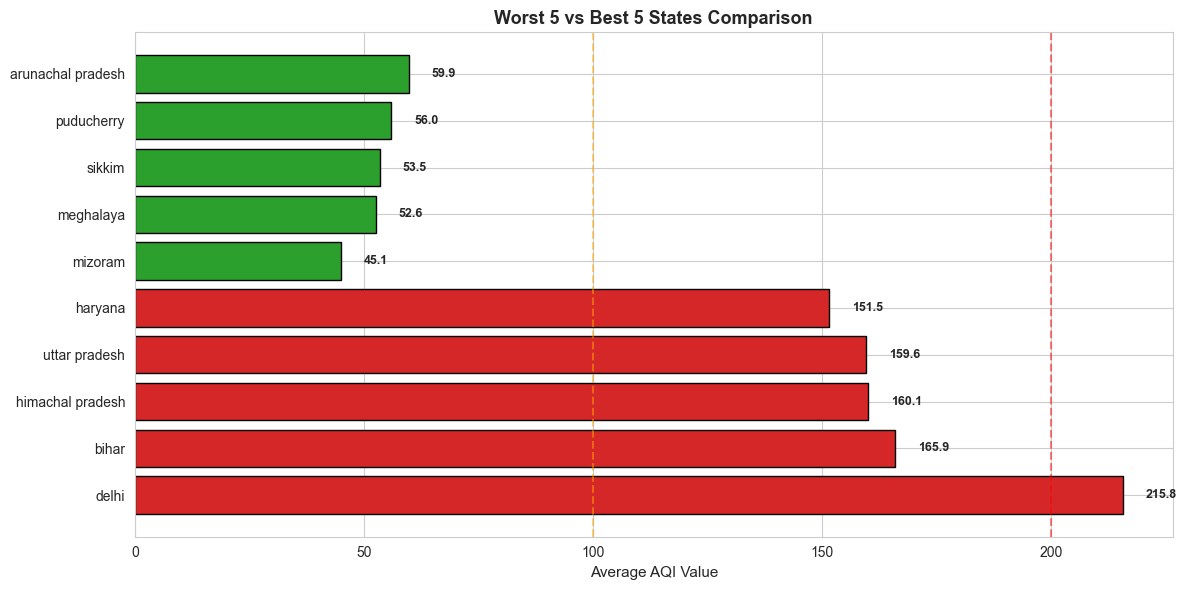


Statistics:
  Worst 5 Average: 170.6
  Best 5 Average:  53.4
  Difference:      117.2 AQI points

  This represents 219% increase


In [14]:
# Compare top 5 worst and best
comparison_data = pd.concat([
    worst_states.head(5),
    best_states.head(5)
])

fig, ax = plt.subplots(figsize=(12, 6))
colors_comp = ['#d62728']*5 + ['#2ca02c']*5
bars = ax.barh(range(len(comparison_data)), comparison_data.values, color=colors_comp, edgecolor='black', linewidth=1)

ax.set_yticks(range(len(comparison_data)))
ax.set_yticklabels(comparison_data.index, fontsize=10)
ax.set_xlabel('Average AQI Value', fontsize=11)
ax.set_title('Worst 5 vs Best 5 States Comparison', fontsize=13, fontweight='bold')

for i, (bar, value) in enumerate(zip(bars, comparison_data.values)):
    ax.text(value + 5, i, f'{value:.1f}', va='center', fontweight='bold', fontsize=9)

ax.axvline(x=100, color='orange', linestyle='--', alpha=0.5)
ax.axvline(x=200, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nStatistics:")
print(f"  Worst 5 Average: {worst_states.head(5).mean():.1f}")
print(f"  Best 5 Average:  {best_states.head(5).mean():.1f}")
print(f"  Difference:      {worst_states.head(5).mean() - best_states.head(5).mean():.1f} AQI points")
print(f"\n  This represents {((worst_states.head(5).mean() - best_states.head(5).mean())/best_states.head(5).mean()*100):.0f}% increase")